In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chi2
from scipy.stats import chisquare, geom, norm, kstwobign
from scipy.stats import t
from time import time
import tracemalloc

In [2]:
def generate_X_geometic(U, p):
    return np.floor(np.log(U) / np.log(1-p)) + 1

def histogram(x, bins=10, text="Histogram of randomly generated number from Geometric distribution"):
    plt.hist(x, bins=bins)
    plt.title(text)
    plt.show()
    
def chi_square_test_geometric(x, p_geom):
    n = len(x)
    k = np.arange(1, max(x) + 2)
    p_i = geom.pmf(k, p_geom)
    p_i[-1] += 1 - np.sum(p_i)  # absorb tail

    n_observed = np.bincount(x)[1:len(k)+1]  # align length to k
    n_observed = np.append(n_observed, np.zeros(len(k) - len(n_observed)))  # pad if needed
    n_expected = n * p_i

    T, p_value = chisquare(n_observed, f_exp=n_expected)
    return T, p_value







For p=0.3:


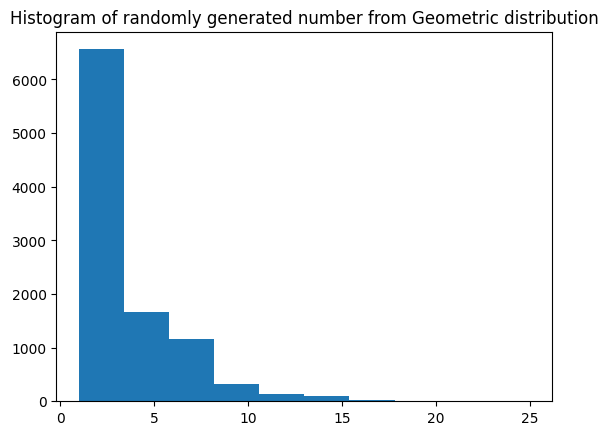

(np.float64(36.914513755538024), np.float64(0.058823743328638524))
Range: 1 25


In [3]:
p = 0.3
U = np.random.rand(10000)


X = generate_X_geometic(U, p).astype(int)
print(f'For p={p}:')
histogram(X)
print(chi_square_test_geometric(X, p))
print("Range:", np.min(X), np.max(X))

For p=0.6:


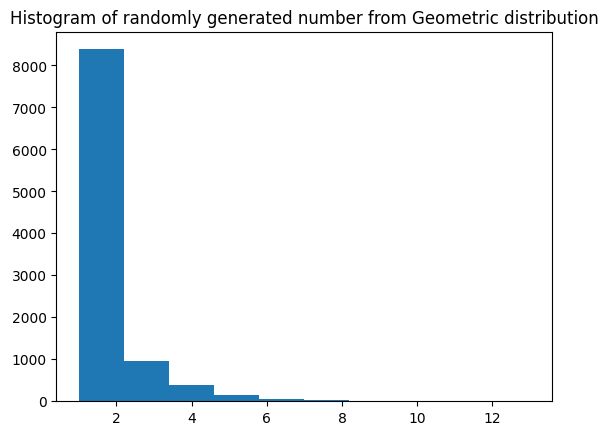

(np.float64(10.331518595379483), np.float64(0.6666261466519241))


In [4]:
p = 0.6
U = np.random.rand(10000)
X = generate_X_geometic(U, p).astype(int)
print(f'For p={p}:')
histogram(X)
print(chi_square_test_geometric(X, p))

For p=0.9:


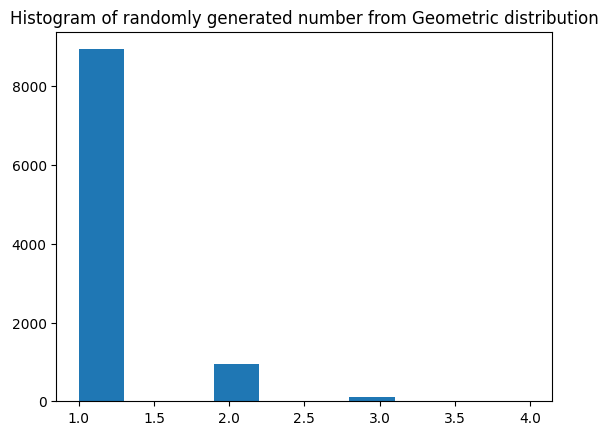

(np.float64(8.797666666666256), np.float64(0.06636068757094987))


In [5]:
p = 0.9
U = np.random.rand(10000)
print(f'For p={p}:')
X = generate_X_geometic(U, p).astype(int)
histogram(X)
print(chi_square_test_geometric(X, p))

## Exercise 2

In [6]:
#Algorithms for sampling from a discrete distribution
p_i = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

def crude_method(p_i, n): # O(n*k)
    U = np.random.rand(n) # O(n)
    F_x = np.cumsum(p_i) # O(k)
    
    F_x_index = U[:, np.newaxis] > F_x[np.newaxis, :] # returns true if U[i] > F_x[j]; O(n*k)
    index = np.argmax(~F_x_index, axis=1) + 1 # finds the first False where U[i] is smaller than F_x[j]; O(n)
    
    return index


def simple_rejection_vectorized(p_i, n, c=None):  # O(n**2)
    k = len(p_i)
    epsilon = 1.5
    if c is None:
        c = np.max(p_i) * epsilon
    
    samples = []
    while len(samples) < n: # O(n)
        U = np.random.rand(n,2) # O(n)
        I = np.floor(k * U[:,0]).astype(int) # O(n)
        accepted = U[:,1] <= p_i[I] / c # O(n)
        
        samples.extend(I[accepted] + 1)
    
    return np.array(samples[:n])


def alias_method(p_i, n):
    k = len(p_i)
    L = np.arange(0, k)   # length k, 0-indexed
    F = k * p_i
    G = list(np.where(F > 1)[0])  # list so we can pop/append
    S = list(np.where(F < 1)[0])

    while len(S) > 0:
        i, j = G[0], S[0] 
        L[j] = i
        F[i] = F[i] - (1 - F[j])
        S.pop(0)  # j is now resolved

        if F[i] < 1:  # i moves from G to S
            G.pop(0)
            S.append(i)
        elif F[i] == 1:  # i is exactly full
            G.pop(0)
            
    U = np.random.rand(n,2)
            
    I = np.int32(np.floor(k*U[:,0]))
    
    tester = np.where(U[:,1] < F[I], I, L[I])
    

    return tester + 1

In [7]:
## Performance Measures
def chi_square_test_discrete(x, p_i):
    n = len(x)
    k = len(p_i)
    
    n_observed = np.bincount(x, minlength=k+1)[1:k+1]  # skip 0, start at 1
    n_expected = n * np.array(p_i)

    if np.any(n_expected < 5):
        print("Warning: some expected counts < 5, chi-square may not be valid")

    T, p_value = chisquare(n_observed, f_exp=n_expected)
    return T, p_value


def kolmogorov_smirnov_test_discrete(x, p_i):
    n = len(x)
    k = len(p_i)
    
    F_n_x = np.cumsum(np.bincount(x, minlength=k+1)[1:]) / n  # skip index 0
    F_x = np.cumsum(p_i)                                        # Theoretical CDF
    
    D_n = np.max(np.abs(F_n_x - F_x))
    p_value = kstwobign.sf(np.sqrt(n) * D_n)
    
    return D_n, p_value


def run_test_1(x):
    median = np.median(x)
    signs = x > median
    
    T = 1 # Test statistc / total number of runs
    for i in range(1, len(signs)):
        if signs[i] == signs[i-1]:
            continue
        else:
            T += 1
        
    n1 = np.sum(signs)
    n2 = len(x) - n1
    
    mu_p = 2 * (n1*n2 / (n1 + n2)) + 1
    sigma_p = 2*n1*n2*(2*n1*n2 - n1 - n2) / ((n1+n2)**2 * (n1+n2-1))
    
    p_value = 1- norm.cdf(T, loc=mu_p, scale=sigma_p )
    
    return T, p_value



def theoretical_mean(p_i):
    k = len(p_i)
    return np.sum((np.arange(1, k+1) * p_i))

def theoretical_variance(p_i):
    k = len(p_i)
    mean = theoretical_mean(p_i)
    return np.sum((np.arange(1, k+1)**2 * p_i)) - mean**2

def CI_mean(means, confidence=0.95):
    n = len(means)
    mean = np.mean(means)
    t_test_statistic = t.ppf(1 - 0.05/2, df=n-1)
    S_n = np.std(means, ddof=1)
    lower_bound = mean - t_test_statistic * S_n / np.sqrt(n)
    upper_bound = mean + t_test_statistic * S_n / np.sqrt(n)
    return mean,lower_bound, upper_bound


def CI_std(stds, confidence=0.95):
    n = len(stds)
    mean = np.mean(stds)
    t_test_statistic = t.ppf(1 - 0.05/2, df=n-1)
    S_n = np.std(stds, ddof=1)
    lower_bound = mean - t_test_statistic * S_n / np.sqrt(n)
    upper_bound = mean + t_test_statistic * S_n / np.sqrt(n)
    return mean,lower_bound, upper_bound


In [8]:
def evaluate_performance(method, p_i, n_runs=100, n_samples=1000):
    means = np.zeros(n_runs)
    stds = np.zeros(n_runs)
    
    start_time = time()
    for i in range(n_runs):
        samples = method(p_i, n_samples)
        means[i] = np.mean(samples)
        stds[i] = np.std(samples, ddof=1)
    end_time = time()
    time_taken = (end_time - start_time)/n_runs
    
    mean_ci = CI_mean(means)
    std_ci = CI_std(stds)
    
    kolmogorov_smirnov = kolmogorov_smirnov_test_discrete(samples, p_i)
    chi_square =chi_square_test_discrete(samples, p_i)
    run_test = run_test_1(samples)
    
    print(f"Method: {method.__name__}")  
    print(f"Time taken: {time_taken:.7f} seconds")
    print(f"Mean CI: {mean_ci}")
    print(f"Std CI: {std_ci}")
    print(f"Chi-square: {chi_square}")
    print(f"Kolmogorov-Smirnov: {kolmogorov_smirnov}")
    print(f"Run test: {run_test}")
    print("-" * 40)

In [9]:
print("Theoretical mean:", theoretical_mean(p_i))
print("Theoretical standard deviation:", np.sqrt(theoretical_variance(p_i)))
print("-" * 40)

evaluate_performance(crude_method, p_i)
evaluate_performance(simple_rejection_vectorized, p_i)
evaluate_performance(alias_method, p_i)

Theoretical mean: 4.104166666666667
Theoretical standard deviation: 1.8284736728272084
----------------------------------------
Method: crude_method
Time taken: 0.0002222 seconds
Mean CI: (np.float64(4.0933600000000006), np.float64(4.082386480576865), np.float64(4.104333519423136))
Std CI: (np.float64(1.8310850016673224), np.float64(1.8263780417620348), np.float64(1.83579196157261))
Chi-square: (np.float64(1.7372571428571444), np.float64(0.8841729654289877))
Kolmogorov-Smirnov: (np.float64(0.015000000000000013), np.float64(0.9780359353159622))
Run test: (433, np.float64(0.4990347652927345))
----------------------------------------
Method: simple_rejection_vectorized
Time taken: 0.0001990 seconds
Mean CI: (np.float64(4.09865), np.float64(4.087313766923636), np.float64(4.109986233076365))
Std CI: (np.float64(1.8320081423740247), np.float64(1.8270836881281798), np.float64(1.8369325966198695))
Chi-square: (np.float64(8.90925714285714), np.float64(0.11273878630330315))
Kolmogorov-Smirnov: (

In [10]:
for method in [crude_method, simple_rejection_vectorized, alias_method]:
    tracemalloc.start()
    method(p_i, 1000)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"{method.__name__}: {peak / 1024:.2f} KB")

crude_method: 110.81 KB
simple_rejection_vectorized: 75.98 KB
alias_method: 46.39 KB
